# ============================================================
# CAPSTONE PROJECT
# NOTEBOOK 30: AUDIO MULTI-LABEL BASELINE (CANDIDATE-150 PILOT)
# ============================================================
# Purpose:
# This notebook builds the first unstructured audio multi-label
# baseline for the 150 candidate metadata genres using raw audio.
#
# The goal is to:
# 1. Load the candidate-150 multi-label master table
# 2. Recreate a deterministic laptop-safe pilot subset
# 3. Build Mel spectrogram generators from raw audio
# 4. Train a multi-label CNN with sigmoid outputs
# 5. Tune a global threshold on the validation set
# 6. Evaluate on the test set
# 7. Save outputs for later hybrid fusion
# ============================================================

In [1]:
# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import os
import gc
import math
import random
import warnings

import joblib
import librosa
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.metrics import (
    f1_score,
    hamming_loss,
    accuracy_score,
    precision_score,
    recall_score
)

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Seeds set to:", SEED)
print("TensorFlow version:", tf.__version__)

Seeds set to: 42
TensorFlow version: 2.20.0


In [2]:
# ============================================================
# 2. LOAD MULTI-LABEL MASTER TABLE
# ============================================================

master_df = pd.read_csv("../data/processed/multilabel_candidate_master_table.csv")

print("Candidate multi-label master shape:", master_df.shape)
display(master_df.head())

Candidate multi-label master shape: (81574, 157)


,track_id,split,subset,genre_top,title,audio_path,audio_exists,genre_1,genre_2,genre_3,...,genre_693,genre_695,genre_741,genre_763,genre_810,genre_811,genre_906,genre_1156,genre_1193,genre_1235
0,20,training,large,NaN,Spiritual Level,../data/raw/audio/fma_large\000\000020.mp3,True,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,26,training,large,NaN,Where is your Love?,../data/raw/audio/fma_large\000\000026.mp3,True,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,30,training,large,NaN,Too Happy,../data/raw/audio/fma_large\000\000030.mp3,True,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,46,training,large,NaN,Yosemite,../data/raw/audio/fma_large\000\000046.mp3,True,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,48,training,large,NaN,Light of Light,../data/raw/audio/fma_large\000\000048.mp3,True,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [3]:
# ============================================================
# 3. IDENTIFY LABEL COLUMNS
# ============================================================

label_cols = [
    col for col in master_df.columns
    if col.startswith("genre_") and col.replace("genre_", "").isdigit()
]

print("Number of candidate label columns:", len(label_cols))
print("First 10 label columns:", label_cols[:10])

print("\nNon-label genre-like columns:")
print([col for col in master_df.columns if col.startswith("genre_") and col not in label_cols])

Number of candidate label columns: 150
First 10 label columns: ['genre_1', 'genre_2', 'genre_3', 'genre_4', 'genre_5', 'genre_6', 'genre_7', 'genre_8', 'genre_9', 'genre_10']

Non-label genre-like columns:
['genre_top']


In [4]:
# ============================================================
# 4. FILTER TO USABLE AUDIO MULTI-LABEL ROWS
# ============================================================

master_df["candidate_label_count"] = master_df[label_cols].sum(axis=1)

usable_df = master_df[
    (master_df["candidate_label_count"] > 0) &
    (master_df["audio_exists"] == True)
].copy().reset_index(drop=True)

print("Original candidate master shape:", master_df.shape)
print("Usable audio multi-label shape:", usable_df.shape)

print("\nSplit distribution:")
print(usable_df["split"].value_counts())

print("\nCandidate label count summary:")
print(usable_df["candidate_label_count"].describe())

Original candidate master shape: (81574, 158)
Usable audio multi-label shape: (79343, 158)

Split distribution:
split
training      62452
test           8548
validation     8343
Name: count, dtype: int64

Candidate label count summary:
count    79343.000000
mean         3.679329
std          1.735141
min          1.000000
25%          3.000000
50%          4.000000
75%          5.000000
max         31.000000
Name: candidate_label_count, dtype: float64


In [5]:
# ============================================================
# 5. RECREATE A DETERMINISTIC LAPTOP-SAFE PILOT SUBSET
# ============================================================

# These caps are intentionally conservative for a laptop.
# Increase later only if this notebook runs comfortably.

TRAIN_CAP = 5000
VAL_CAP = 1000
TEST_CAP = 1000

def sample_split(df, split_name, n, seed=42):
    sub = df[df["split"] == split_name].copy()
    if len(sub) > n:
        sub = sub.sample(n=n, random_state=seed)
    sub = sub.sort_values("track_id").reset_index(drop=True)
    return sub

train_df = sample_split(usable_df, "training", TRAIN_CAP, seed=SEED)
val_df = sample_split(usable_df, "validation", VAL_CAP, seed=SEED)
test_df = sample_split(usable_df, "test", TEST_CAP, seed=SEED)

print("Pilot split sizes:")
print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

print("\nAverage labels per track in pilot:")
print("Train:", train_df[label_cols].sum(axis=1).mean())
print("Validation:", val_df[label_cols].sum(axis=1).mean())
print("Test:", test_df[label_cols].sum(axis=1).mean())

Pilot split sizes:
Train: (5000, 158)
Validation: (1000, 158)
Test: (1000, 158)

Average labels per track in pilot:
Train: 3.6398
Validation: 3.918
Test: 3.732


In [6]:
# ============================================================
# 6. CHECK LABEL COVERAGE IN THE PILOT
# ============================================================

train_label_counts = train_df[label_cols].sum(axis=0)
val_label_counts = val_df[label_cols].sum(axis=0)
test_label_counts = test_df[label_cols].sum(axis=0)

print("Labels present in train:", int((train_label_counts > 0).sum()), "out of", len(label_cols))
print("Labels present in validation:", int((val_label_counts > 0).sum()), "out of", len(label_cols))
print("Labels present in test:", int((test_label_counts > 0).sum()), "out of", len(label_cols))

print("\nTrain label count summary:")
print(train_label_counts.describe())

Labels present in train: 147 out of 150
Labels present in validation: 140 out of 150
Labels present in test: 135 out of 150

Train label count summary:
count     150.000000
mean      121.326667
std       290.941252
min         0.000000
25%         7.250000
50%        31.000000
75%        96.750000
max      2229.000000
dtype: float64


In [7]:
# ============================================================
# 7. SAVE PILOT SPLIT METADATA
# ============================================================

os.makedirs("../data/processed", exist_ok=True)

train_df.to_csv("../data/processed/audio_multilabel_candidate150_pilot_train.csv", index=False)
val_df.to_csv("../data/processed/audio_multilabel_candidate150_pilot_val.csv", index=False)
test_df.to_csv("../data/processed/audio_multilabel_candidate150_pilot_test.csv", index=False)

print("Saved pilot split metadata.")

Saved pilot split metadata.


In [8]:
# ============================================================
# 8. AUDIO PREPROCESSING SETTINGS
# ============================================================

SR = 22050
DURATION = 15  # shorter than 30s for laptop safety
N_MELS = 64
N_FFT = 2048
HOP_LENGTH = 1024

MAX_FRAMES = int(np.ceil((DURATION * SR) / HOP_LENGTH)) + 1

BATCH_SIZE = 8
NUM_LABELS = len(label_cols)

print("SR:", SR)
print("DURATION:", DURATION)
print("N_MELS:", N_MELS)
print("MAX_FRAMES:", MAX_FRAMES)
print("BATCH_SIZE:", BATCH_SIZE)
print("NUM_LABELS:", NUM_LABELS)

SR: 22050
DURATION: 15
N_MELS: 64
MAX_FRAMES: 324
BATCH_SIZE: 8
NUM_LABELS: 150


In [9]:
# ============================================================
# 9. AUDIO LOADING HELPER
# ============================================================

bad_audio_paths = set()

def safe_load_melspectrogram(file_path, sr=SR, duration=DURATION,
                             n_mels=N_MELS, n_fft=N_FFT, hop_length=HOP_LENGTH,
                             max_frames=MAX_FRAMES):
    try:
        y, _ = librosa.load(file_path, sr=sr, mono=True, duration=duration)

        if y is None or len(y) == 0:
            bad_audio_paths.add(file_path)
            return np.zeros((n_mels, max_frames), dtype=np.float32)

        mel = librosa.feature.melspectrogram(
            y=y,
            sr=sr,
            n_fft=n_fft,
            hop_length=hop_length,
            n_mels=n_mels
        )

        mel_db = librosa.power_to_db(mel, ref=np.max)

        # Normalize from roughly [-80, 0] dB to [0, 1]
        mel_db = np.clip((mel_db + 80.0) / 80.0, 0.0, 1.0)

        # Pad or truncate time axis
        if mel_db.shape[1] < max_frames:
            pad_width = max_frames - mel_db.shape[1]
            mel_db = np.pad(mel_db, ((0, 0), (0, pad_width)), mode="constant")
        else:
            mel_db = mel_db[:, :max_frames]

        return mel_db.astype(np.float32)

    except Exception:
        bad_audio_paths.add(file_path)
        return np.zeros((n_mels, max_frames), dtype=np.float32)

In [10]:
# ============================================================
# 10. KERAS SEQUENCE GENERATOR
# ============================================================

class AudioMultiLabelSequence(tf.keras.utils.Sequence):
    def __init__(self, df, label_cols, batch_size=BATCH_SIZE, shuffle=False, **kwargs):
        super().__init__(**kwargs)
        self.df = df.reset_index(drop=True).copy()
        self.label_cols = label_cols
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.indices = np.arange(len(self.df))
        self.on_epoch_end()

    def __len__(self):
        return math.ceil(len(self.df) / self.batch_size)

    def __getitem__(self, idx):
        batch_idx = self.indices[idx * self.batch_size:(idx + 1) * self.batch_size]
        batch_df = self.df.iloc[batch_idx]

        X_batch = np.zeros((len(batch_df), N_MELS, MAX_FRAMES, 1), dtype=np.float32)
        y_batch = np.zeros((len(batch_df), len(self.label_cols)), dtype=np.float32)

        for i, (_, row) in enumerate(batch_df.iterrows()):
            mel = safe_load_melspectrogram(row["audio_path"])
            X_batch[i, :, :, 0] = mel
            y_batch[i] = row[self.label_cols].values.astype(np.float32)

        return X_batch, y_batch

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)

In [11]:
# ============================================================
# 11. CREATE GENERATORS
# ============================================================

train_gen = AudioMultiLabelSequence(train_df, label_cols, batch_size=BATCH_SIZE, shuffle=True)
val_gen = AudioMultiLabelSequence(val_df, label_cols, batch_size=BATCH_SIZE, shuffle=False)
test_gen = AudioMultiLabelSequence(test_df, label_cols, batch_size=BATCH_SIZE, shuffle=False)

print("Train batches:", len(train_gen))
print("Validation batches:", len(val_gen))
print("Test batches:", len(test_gen))

sample_X, sample_y = train_gen[0]
print("Sample batch X shape:", sample_X.shape)
print("Sample batch y shape:", sample_y.shape)

Train batches: 625
Validation batches: 125
Test batches: 125
Sample batch X shape: (8, 64, 324, 1)
Sample batch y shape: (8, 150)


In [12]:
# ============================================================
# 12. BUILD THE MULTI-LABEL AUDIO CNN
# ============================================================

tf.keras.backend.clear_session()
gc.collect()

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(N_MELS, MAX_FRAMES, 1)),

    tf.keras.layers.Conv2D(16, (3, 3), activation="relu", padding="same"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D((2, 2)),

    tf.keras.layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D((2, 2)),

    tf.keras.layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D((2, 2)),

    tf.keras.layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    tf.keras.layers.BatchNormalization(),

    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(NUM_LABELS, activation="sigmoid")
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=[
        tf.keras.metrics.BinaryAccuracy(name="bin_acc"),
        tf.keras.metrics.AUC(name="auc", multi_label=True, num_labels=NUM_LABELS)
    ]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 324, 16)    │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 324, 16)    │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 162, 16)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 162, 32)    │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 162, 32)    │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 81, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 81, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 81, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 40, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 8, 40, 64)      │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 8, 40, 64)      │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 150)            │        19,350 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 88,598 (346.09 KB)

 Trainable params: 88,246 (344.71 KB)

 Non-trainable params: 352 (1.38 KB)

In [13]:
# ============================================================
# 13. TRAIN THE AUDIO MULTI-LABEL MODEL
# ============================================================

os.makedirs("../models", exist_ok=True)

checkpoint_path = "../models/audio_multilabel_candidate150_pilot_best.keras"

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_auc",
    mode="max",
    patience=3,
    restore_best_weights=True
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_auc",
    mode="max",
    factor=0.5,
    patience=2,
    min_lr=1e-5
)

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    checkpoint_path,
    monitor="val_auc",
    mode="max",
    save_best_only=True,
    verbose=1
)

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10,
    callbacks=[early_stop, reduce_lr, checkpoint],
    verbose=1
)

# Reload best checkpoint if it exists
if os.path.exists(checkpoint_path):
    model = tf.keras.models.load_model(checkpoint_path)

print("Training complete.")

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 794ms/step - auc: 0.4574 - bin_acc: 0.9378 - loss: 0.1881
Epoch 1: val_auc improved from -inf to 0.53539, saving model to ../models/audio_multilabel_candidate150_pilot_best.keras
625/625 ━━━━━━━━━━━━━━━━━━━━ 580s 925ms/step - auc: 0.4575 - bin_acc: 0.9379 - loss: 0.1879 - val_auc: 0.5354 - val_bin_acc: 0.9745 - val_loss: 0.0899 - learning_rate: 0.0010
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 399ms/step - auc: 0.5128 - bin_acc: 0.9759 - loss: 0.0828
Epoch 2: val_auc improved from 0.53539 to 0.56196, saving model to ../models/audio_multilabel_candidate150_pilot_best.keras
625/625 ━━━━━━━━━━━━━━━━━━━━ 302s 483ms/step - auc: 0.5129 - bin_acc: 0.9759 - loss: 0.0828 - val_auc: 0.5620 - val_bin_acc: 0.9754 - val_loss: 0.0880 - learning_rate: 0.0010
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 439ms/step - auc: 0.5532 - bin_acc: 0.9769 - loss: 0.0781
Epoch 3: val_auc did not improve from 0.56196
625/625 ━━━━━━━━━━━━━━━━━━━━ 325s 520ms/step - auc: 0.55

,auc,bin_acc,loss,val_auc,val_bin_acc,val_loss,learning_rate
0,0.521904,0.967528,0.112919,0.535394,0.974500,0.089909,0.001
1,0.563044,0.976487,0.080966,0.561957,0.975373,0.088004,0.001
2,0.598433,0.977171,0.077666,0.549675,0.973953,0.093606,0.001
3,0.618143,0.977331,0.076124,0.563961,0.974740,0.090828,0.001
4,0.628546,0.977545,0.075211,0.536291,0.973900,0.097877,0.001


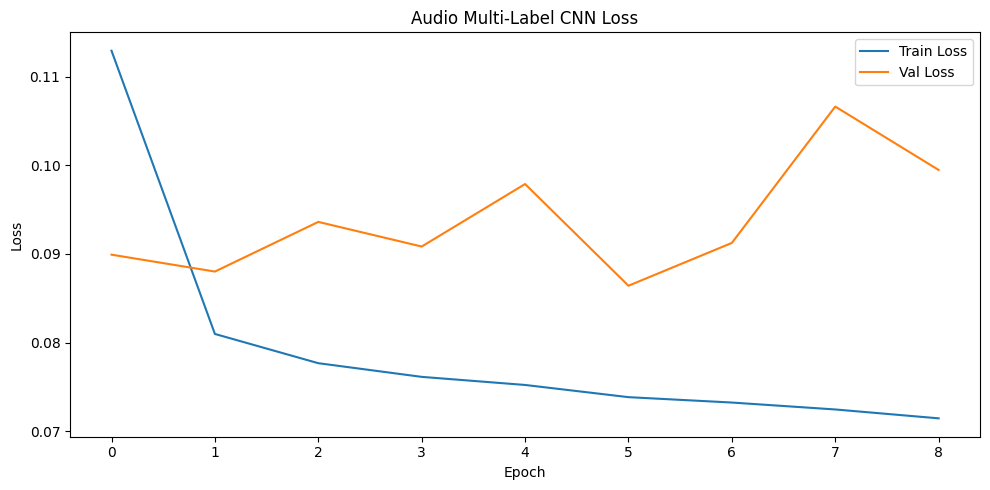

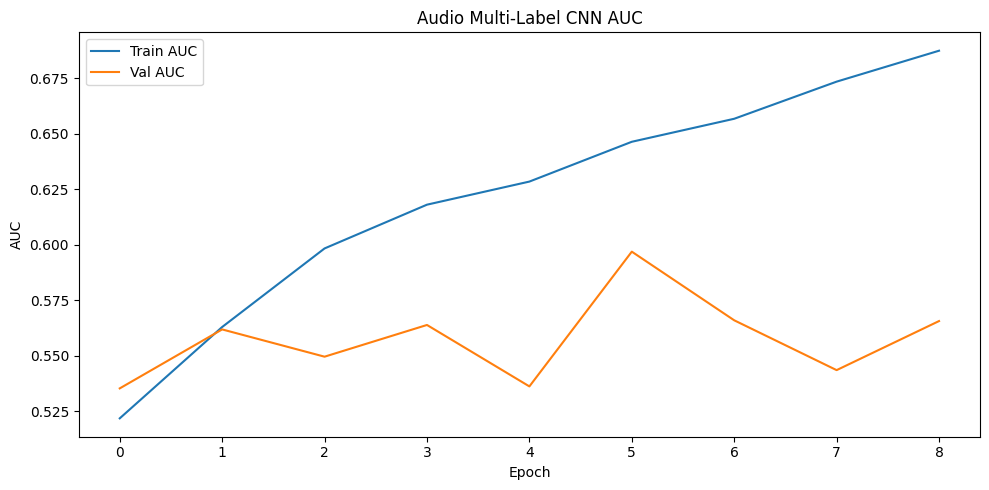

In [14]:
# ============================================================
# 14. PLOT TRAINING CURVES
# ============================================================

history_df = pd.DataFrame(history.history)
display(history_df.head())

plt.figure(figsize=(10, 5))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.title("Audio Multi-Label CNN Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(history.history["auc"], label="Train AUC")
plt.plot(history.history["val_auc"], label="Val AUC")
plt.title("Audio Multi-Label CNN AUC")
plt.xlabel("Epoch")
plt.ylabel("AUC")
plt.legend()
plt.tight_layout()
plt.show()

In [15]:
# ============================================================
# 15. PREDICT VALIDATION AND TEST PROBABILITIES
# ============================================================

val_probs = model.predict(val_gen, verbose=1)
test_probs = model.predict(test_gen, verbose=1)

Y_val = val_df[label_cols].values.astype(np.uint8)
Y_test = test_df[label_cols].values.astype(np.uint8)

print("Validation probabilities shape:", val_probs.shape)
print("Test probabilities shape:", test_probs.shape)
print("Y_val shape:", Y_val.shape)
print("Y_test shape:", Y_test.shape)

125/125 ━━━━━━━━━━━━━━━━━━━━ 30s 239ms/step
125/125 ━━━━━━━━━━━━━━━━━━━━ 76s 613ms/step
Validation probabilities shape: (1000, 150)
Test probabilities shape: (1000, 150)
Y_val shape: (1000, 150)
Y_test shape: (1000, 150)


In [16]:
# ============================================================
# 16. EVALUATION HELPERS
# ============================================================

def evaluate_multilabel(y_true, y_pred, name="Model"):
    return {
        "Model": name,
        "Micro F1": f1_score(y_true, y_pred, average="micro", zero_division=0),
        "Macro F1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "Samples F1": f1_score(y_true, y_pred, average="samples", zero_division=0),
        "Micro Precision": precision_score(y_true, y_pred, average="micro", zero_division=0),
        "Micro Recall": recall_score(y_true, y_pred, average="micro", zero_division=0),
        "Hamming Loss": hamming_loss(y_true, y_pred),
        "Subset Accuracy": accuracy_score(y_true, y_pred),
        "Avg Predicted Labels": float(y_pred.sum(axis=1).mean())
    }

def precision_recall_at_k(y_true, score_matrix, k=3):
    y_true = np.asarray(y_true)
    topk_idx = np.argsort(-score_matrix, axis=1)[:, :k]

    precision_vals = []
    recall_vals = []

    for i in range(y_true.shape[0]):
        true_idx = np.where(y_true[i] == 1)[0]
        if len(true_idx) == 0:
            continue

        pred_idx = topk_idx[i]
        hits = len(set(pred_idx).intersection(set(true_idx)))

        precision_vals.append(hits / k)
        recall_vals.append(hits / len(true_idx))

    return float(np.mean(precision_vals)), float(np.mean(recall_vals))

def decode_threshold(prob_matrix, threshold, ensure_at_least_one=False):
    y_pred = (prob_matrix >= threshold).astype(np.uint8)

    if ensure_at_least_one:
        row_sums = y_pred.sum(axis=1)
        zero_rows = np.where(row_sums == 0)[0]

        if len(zero_rows) > 0:
            top_idx = np.argmax(prob_matrix[zero_rows], axis=1)
            y_pred[zero_rows, top_idx] = 1

    return y_pred

In [17]:
# ============================================================
# 17. DEFAULT THRESHOLD EVALUATION
# ============================================================

default_threshold = 0.5

Y_val_pred_default = decode_threshold(val_probs, default_threshold, ensure_at_least_one=False)
Y_test_pred_default = decode_threshold(test_probs, default_threshold, ensure_at_least_one=False)

default_val_results = evaluate_multilabel(
    Y_val, Y_val_pred_default, name="Audio Multi-Label CNN - Default Threshold"
)
default_test_results = evaluate_multilabel(
    Y_test, Y_test_pred_default, name="Audio Multi-Label CNN - Default Threshold"
)

p3_val, r3_val = precision_recall_at_k(Y_val, val_probs, k=3)
p5_val, r5_val = precision_recall_at_k(Y_val, val_probs, k=5)

default_val_results["Precision@3"] = p3_val
default_val_results["Recall@3"] = r3_val
default_val_results["Precision@5"] = p5_val
default_val_results["Recall@5"] = r5_val

p3_test, r3_test = precision_recall_at_k(Y_test, test_probs, k=3)
p5_test, r5_test = precision_recall_at_k(Y_test, test_probs, k=5)

default_test_results["Precision@3"] = p3_test
default_test_results["Recall@3"] = r3_test
default_test_results["Precision@5"] = p5_test
default_test_results["Recall@5"] = r5_test

print("Default validation results:")
print(default_val_results)

print("\nDefault test results:")
print(default_test_results)

Default validation results:
{'Model': 'Audio Multi-Label CNN - Default Threshold', 'Micro F1': 0.2627067968905721, 'Macro F1': 0.011923403482838657, 'Samples F1': 0.2596798867798868, 'Micro Precision': 0.5996360327570519, 'Micro Recall': 0.16819806023481368, 'Hamming Loss': 0.02466, 'Subset Accuracy': 0.014, 'Avg Predicted Labels': 1.099, 'Precision@3': 0.41333333333333333, 'Recall@3': 0.34713134920634925, 'Precision@5': 0.31660000000000005, 'Recall@5': 0.43624801587301587}

Default test results:
{'Model': 'Audio Multi-Label CNN - Default Threshold', 'Micro F1': 0.25031236984589755, 'Macro F1': 0.0132481617109384, 'Samples F1': 0.24722401487401485, 'Micro Precision': 0.5616822429906542, 'Micro Recall': 0.1610396570203644, 'Hamming Loss': 0.024, 'Subset Accuracy': 0.006, 'Avg Predicted Labels': 1.07, 'Precision@3': 0.4026666666666666, 'Recall@3': 0.3546013347763348, 'Precision@5': 0.31300000000000006, 'Recall@5': 0.44974148629148636}


In [18]:
# ============================================================
# 18. GLOBAL THRESHOLD SEARCH ON VALIDATION
# ============================================================

threshold_grid = np.arange(0.05, 0.65, 0.05)

threshold_results = []

for t in threshold_grid:
    Y_val_pred_t = decode_threshold(val_probs, t, ensure_at_least_one=False)

    results = evaluate_multilabel(
        Y_val,
        Y_val_pred_t,
        name=f"Audio CNN @ {t:.2f}"
    )

    results["Threshold"] = float(t)
    threshold_results.append(results)

threshold_results_df = pd.DataFrame(threshold_results).sort_values(
    "Micro F1", ascending=False
).reset_index(drop=True)

print("Validation threshold search:")
display(threshold_results_df)

Validation threshold search:


,Model,Micro F1,Macro F1,Samples F1,Micro Precision,Micro Recall,Hamming Loss,Subset Accuracy,Avg Predicted Labels,Threshold
0,Audio CNN @ 0.15,0.356580,0.038049,0.352390,0.322527,0.398673,0.037580,0.000,4.843,0.15
1,Audio CNN @ 0.20,0.355382,0.031234,0.351025,0.391051,0.325676,0.030860,0.002,3.263,0.20
2,Audio CNN @ 0.25,0.345283,0.025167,0.343139,0.449631,0.280245,0.027760,0.003,2.442,0.25
3,Audio CNN @ 0.10,0.335206,0.048562,0.331253,0.251469,0.502552,0.052067,0.000,7.830,0.10
4,Audio CNN @ 0.30,0.331912,0.021225,0.330485,0.500257,0.248341,0.026113,0.010,1.945,0.30
5,Audio CNN @ 0.35,0.315449,0.017221,0.315020,0.531118,0.224349,0.025433,0.009,1.655,0.35
6,Audio CNN @ 0.40,0.297896,0.014486,0.298101,0.550585,0.204186,0.025140,0.010,1.453,0.40
7,Audio CNN @ 0.45,0.281972,0.012878,0.280519,0.574568,0.186830,0.024853,0.013,1.274,0.45
8,Audio CNN @ 0.05,0.271467,0.061734,0.270678,0.171588,0.649566,0.091067,0.000,14.832,0.05
9,Audio CNN @ 0.50,0.262707,0.011923,0.259680,0.599636,0.168198,0.024660,0.014,1.099,0.50


In [19]:
# ============================================================
# 19. SELECT BEST THRESHOLD
# ============================================================

best_threshold = float(threshold_results_df.iloc[0]["Threshold"])
best_val_micro_f1 = float(threshold_results_df.iloc[0]["Micro F1"])

print("Best threshold:", best_threshold)
print("Best validation Micro F1:", best_val_micro_f1)

Best threshold: 0.15000000000000002
Best validation Micro F1: 0.35658029905261956


In [20]:
# ============================================================
# 20. APPLY BEST THRESHOLD TO TEST
# ============================================================

Y_val_pred_tuned = decode_threshold(val_probs, best_threshold, ensure_at_least_one=False)
Y_test_pred_tuned = decode_threshold(test_probs, best_threshold, ensure_at_least_one=False)

tuned_val_results = evaluate_multilabel(
    Y_val, Y_val_pred_tuned, name="Audio Multi-Label CNN - Tuned Threshold"
)
tuned_test_results = evaluate_multilabel(
    Y_test, Y_test_pred_tuned, name="Audio Multi-Label CNN - Tuned Threshold"
)

tuned_val_results["Precision@3"] = p3_val
tuned_val_results["Recall@3"] = r3_val
tuned_val_results["Precision@5"] = p5_val
tuned_val_results["Recall@5"] = r5_val

tuned_test_results["Precision@3"] = p3_test
tuned_test_results["Recall@3"] = r3_test
tuned_test_results["Precision@5"] = p5_test
tuned_test_results["Recall@5"] = r5_test

print("Tuned validation results:")
print(tuned_val_results)

print("\nTuned test results:")
print(tuned_test_results)

Tuned validation results:
{'Model': 'Audio Multi-Label CNN - Tuned Threshold', 'Micro F1': 0.35658029905261956, 'Macro F1': 0.03804897259136516, 'Samples F1': 0.35239049006549006, 'Micro Precision': 0.32252735907495356, 'Micro Recall': 0.39867279224093927, 'Hamming Loss': 0.03758, 'Subset Accuracy': 0.0, 'Avg Predicted Labels': 4.843, 'Precision@3': 0.41333333333333333, 'Recall@3': 0.34713134920634925, 'Precision@5': 0.31660000000000005, 'Recall@5': 0.43624801587301587}

Tuned test results:
{'Model': 'Audio Multi-Label CNN - Tuned Threshold', 'Micro F1': 0.3623767026773133, 'Macro F1': 0.04285587228633544, 'Samples F1': 0.3578932577226695, 'Micro Precision': 0.3225334448160535, 'Micro Recall': 0.4134512325830654, 'Hamming Loss': 0.0362, 'Subset Accuracy': 0.001, 'Avg Predicted Labels': 4.784, 'Precision@3': 0.4026666666666666, 'Recall@3': 0.3546013347763348, 'Precision@5': 0.31300000000000006, 'Recall@5': 0.44974148629148636}


In [21]:
# ============================================================
# 21. COMPARE DEFAULT VS TUNED TEST RESULTS
# ============================================================

test_comparison_df = pd.DataFrame([
    default_test_results,
    tuned_test_results
])

print("Default vs Tuned Test Comparison:")
display(test_comparison_df)

Default vs Tuned Test Comparison:


,Model,Micro F1,Macro F1,Samples F1,Micro Precision,Micro Recall,Hamming Loss,Subset Accuracy,Avg Predicted Labels,Precision@3,Recall@3,Precision@5,Recall@5
0,Audio Multi-Label CNN - Default Threshold,0.250312,0.013248,0.247224,0.561682,0.161040,0.0240,0.006,1.070,0.402667,0.354601,0.313,0.449741
1,Audio Multi-Label CNN - Tuned Threshold,0.362377,0.042856,0.357893,0.322533,0.413451,0.0362,0.001,4.784,0.402667,0.354601,0.313,0.449741


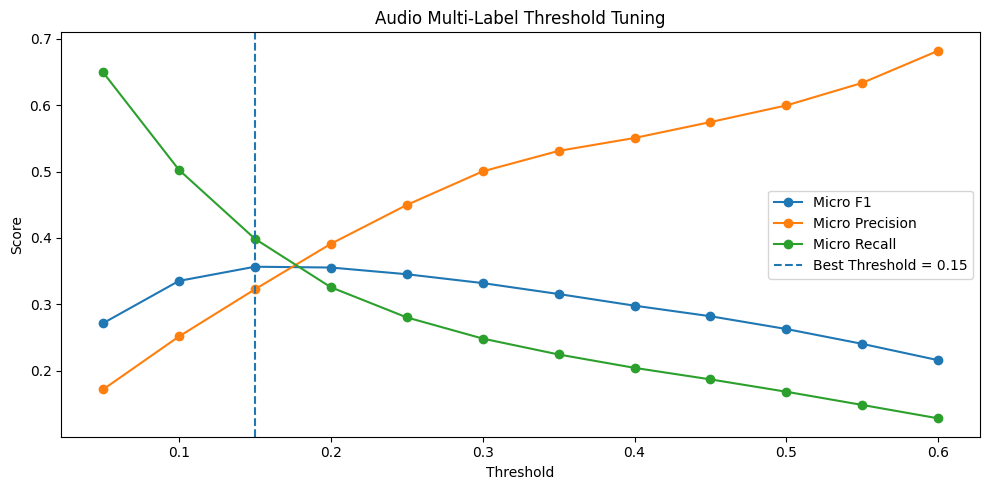

In [22]:
# ============================================================
# 22. PLOT THRESHOLD TUNING CURVE
# ============================================================

plot_df = threshold_results_df.sort_values("Threshold")

plt.figure(figsize=(10, 5))
plt.plot(plot_df["Threshold"], plot_df["Micro F1"], marker="o", label="Micro F1")
plt.plot(plot_df["Threshold"], plot_df["Micro Precision"], marker="o", label="Micro Precision")
plt.plot(plot_df["Threshold"], plot_df["Micro Recall"], marker="o", label="Micro Recall")
plt.axvline(best_threshold, linestyle="--", label=f"Best Threshold = {best_threshold:.2f}")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Audio Multi-Label Threshold Tuning")
plt.legend()
plt.tight_layout()
plt.show()

In [23]:
# ============================================================
# 23. REPORT BAD AUDIO FILES ENCOUNTERED
# ============================================================

print("Number of unreadable/problem audio files encountered:", len(bad_audio_paths))

if len(bad_audio_paths) > 0:
    print("First few problematic paths:")
    print(list(bad_audio_paths)[:10])

Number of unreadable/problem audio files encountered: 13
First few problematic paths:
['../data/raw/audio/fma_large\\155\\155051.mp3', '../data/raw/audio/fma_large\\029\\029352.mp3', '../data/raw/audio/fma_large\\029\\029345.mp3', '../data/raw/audio/fma_large\\025\\025173.mp3', '../data/raw/audio/fma_large\\092\\092479.mp3', '../data/raw/audio/fma_large\\148\\148786.mp3', '../data/raw/audio/fma_large\\101\\101265.mp3', '../data/raw/audio/fma_large\\098\\098562.mp3', '../data/raw/audio/fma_large\\130\\130751.mp3', '../data/raw/audio/fma_large\\054\\054582.mp3']


In [24]:
# ============================================================
# 24. SAVE OUTPUTS FOR LATER HYBRID FUSION
# ============================================================

os.makedirs("../models", exist_ok=True)
os.makedirs("../data/processed", exist_ok=True)

model.save("../models/audio_multilabel_candidate150_pilot_final.keras")

history_df.to_csv(
    "../data/processed/audio_multilabel_candidate150_pilot_history.csv",
    index=False
)

threshold_results_df.to_csv(
    "../data/processed/audio_multilabel_candidate150_pilot_threshold_search.csv",
    index=False
)

pd.DataFrame([default_test_results]).to_csv(
    "../data/processed/audio_multilabel_candidate150_pilot_default_test_results.csv",
    index=False
)

pd.DataFrame([tuned_test_results]).to_csv(
    "../data/processed/audio_multilabel_candidate150_pilot_tuned_test_results.csv",
    index=False
)

test_comparison_df.to_csv(
    "../data/processed/audio_multilabel_candidate150_pilot_test_comparison.csv",
    index=False
)

np.save("../data/processed/audio_multilabel_candidate150_pilot_val_probs.npy", val_probs)
np.save("../data/processed/audio_multilabel_candidate150_pilot_test_probs.npy", test_probs)

np.save("../data/processed/audio_multilabel_candidate150_pilot_y_val.npy", Y_val)
np.save("../data/processed/audio_multilabel_candidate150_pilot_y_test.npy", Y_test)

np.save("../data/processed/audio_multilabel_candidate150_pilot_val_track_ids.npy", val_df["track_id"].values)
np.save("../data/processed/audio_multilabel_candidate150_pilot_test_track_ids.npy", test_df["track_id"].values)

np.save("../data/processed/audio_multilabel_candidate150_pilot_label_columns.npy", np.array(label_cols))

with open("../data/processed/audio_multilabel_candidate150_pilot_best_threshold.txt", "w") as f:
    f.write(str(best_threshold))

print("Saved audio multi-label pilot outputs.")

Saved audio multi-label pilot outputs.


In [25]:
# ============================================================
# 25. INTERPRETATION NOTES
# ============================================================

print("1. This notebook builds the first unstructured audio multi-label baseline for the candidate-150 label space.")
print("2. A laptop-safe pilot subset was used to avoid exhausting memory and compute.")
print("3. The model predicts multi-label genre probabilities directly from raw audio via Mel spectrograms.")
print("4. Validation threshold tuning was used to choose a better decision cutoff for the multi-label predictions.")
print("5. The saved probabilities, labels, and track IDs will later support hybrid multi-label fusion.")

1. This notebook builds the first unstructured audio multi-label baseline for the candidate-150 label space.
2. A laptop-safe pilot subset was used to avoid exhausting memory and compute.
3. The model predicts multi-label genre probabilities directly from raw audio via Mel spectrograms.
4. Validation threshold tuning was used to choose a better decision cutoff for the multi-label predictions.
5. The saved probabilities, labels, and track IDs will later support hybrid multi-label fusion.
